# KJV Full Similarity Analysis

This notebook explores how semantically similar every verse in the King James Bible is to every other verse — all 31,102 of them.

## Background: how does a computer measure meaning?

Modern AI models can read text and produce a list of numbers — called an **embedding** — that captures the meaning of that text. Two passages with similar meanings will produce embeddings that point in roughly the same direction in this high-dimensional space. We measure that "sameness of direction" using a score called **cosine similarity**, which ranges from 0 to 1:

- **0** — the two passages share essentially no semantic content (completely unrelated)
- **0.5** — moderate overlap in theme or vocabulary
- **1.0** — the passages are essentially identical in meaning

By computing this score for every possible pair of verses, we can build a full map of how the Bible's ideas connect to each other.

## What this notebook produces

- **A histogram** of similarity scores across millions of random verse pairs — showing the overall shape of how related verses tend to be
- **A genre-level heatmap** (10×10) — which broad sections of the Bible (e.g., Psalms, Pauline Epistles, Gospels) are most similar to each other?
- **A book-level heatmap** (66×66) — the same question at the level of individual books
- **Binary verse-level heatmaps** — a bird's-eye view of all 31k verses at once, highlighting which pairs cross a given similarity threshold

**Note:** The full matrix requires storing a score for every possible pair of verses, which works out to roughly 3.7 GB in memory. Make sure you have at least 6 GB of free RAM before running the next cell.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path
import torch

from sacred_semantics.corpus.bible import load_segments
from sacred_semantics.pipeline.embed import load as load_embeddings

segments = load_segments(Path('../data/processed/bible_kjv.json'))
embeddings = load_embeddings(Path('../embeddings/bible_kjv_all_mpnet_base_v2.npy'))

print(f'Segments:   {len(segments):,}')
print(f'Embeddings: {embeddings.shape}')
print(f'CUDA:       {torch.cuda.is_available()}')

Segments:   31,102
Embeddings: (31102, 768)
CUDA:       True


## 1. Compute the full similarity matrix

A **similarity matrix** is a grid where each row and each column represents one verse. The number in any cell is the cosine similarity score between those two verses. Because we have 31,102 verses, the grid is 31,102 × 31,102 — over 960 million scores in total.

To keep this manageable, we compute the scores in batches ("chunks") using the GPU, which can handle thousands of calculations simultaneously. If no GPU is available the code falls back to the CPU, which will be slower but still correct. Once computed, the matrix is saved to disk so it only needs to be calculated once.

The resulting file is about 3.9 GB.

In [2]:
SIM_PATH = Path('../embeddings/bible_kjv_all_mpnet_base_v2_similarity.npy')

def compute_similarity_matrix(embeddings: np.ndarray, chunk_size: int = 2000) -> np.ndarray:
    n = len(embeddings)
    result = np.empty((n, n), dtype=np.float32)

    if torch.cuda.is_available():
        emb = torch.from_numpy(embeddings).float()
        normed = (emb / emb.norm(dim=1, keepdim=True)).cuda()
        for i in range(0, n, chunk_size):
            batch = normed[i:i + chunk_size]
            result[i:i + chunk_size] = (batch @ normed.T).cpu().numpy()
            if (i // chunk_size) % 5 == 0:
                print(f'  {i:,} / {n:,}', end='\r')
        print(f'  {n:,} / {n:,} — done')
    else:
        from sklearn.preprocessing import normalize
        normed = normalize(embeddings).astype(np.float32)
        result = normed @ normed.T

    return result

if SIM_PATH.exists():
    print(f'Loading cached matrix from {SIM_PATH} ...')
    sim = np.load(SIM_PATH)
else:
    print('Computing similarity matrix (this takes a few minutes) ...')
    sim = compute_similarity_matrix(embeddings)
    print(f'Saving to {SIM_PATH} ...')
    np.save(SIM_PATH, sim)

print(f'Matrix shape: {sim.shape}  dtype: {sim.dtype}  size: {sim.nbytes / 1e9:.1f} GB')

Loading cached matrix from ..\embeddings\bible_kjv_all_mpnet_base_v2_similarity.npy ...
Matrix shape: (31102, 31102)  dtype: float32  size: 3.9 GB


## 2. Histogram of pairwise similarities

Rather than looking at every one of the 960 million scores, we randomly sample 2 million verse pairs and plot their distribution. Because we only want unique pairs (not "Genesis 1:1 vs Genesis 1:1"), we restrict to the upper triangle of the matrix — pairs where the first verse comes before the second.

**How to read the histogram:** The x-axis is the similarity score (0 = unrelated, 1 = identical), and the y-axis is how many pairs landed at that score. A tall spike at a low score (say, 0.1–0.3) would mean most pairs of verses have little in common — which is expected. A secondary "bump" at a higher score would reveal a cluster of meaningfully related pairs.

The original hypothesis was that we'd see a **bimodal distribution** — two humps — one for the bulk of unrelated pairs and one for a distinct group of thematically related pairs. The right-hand panel zooms in on the high-similarity tail (scores above 0.5) so we can see this structure more clearly.

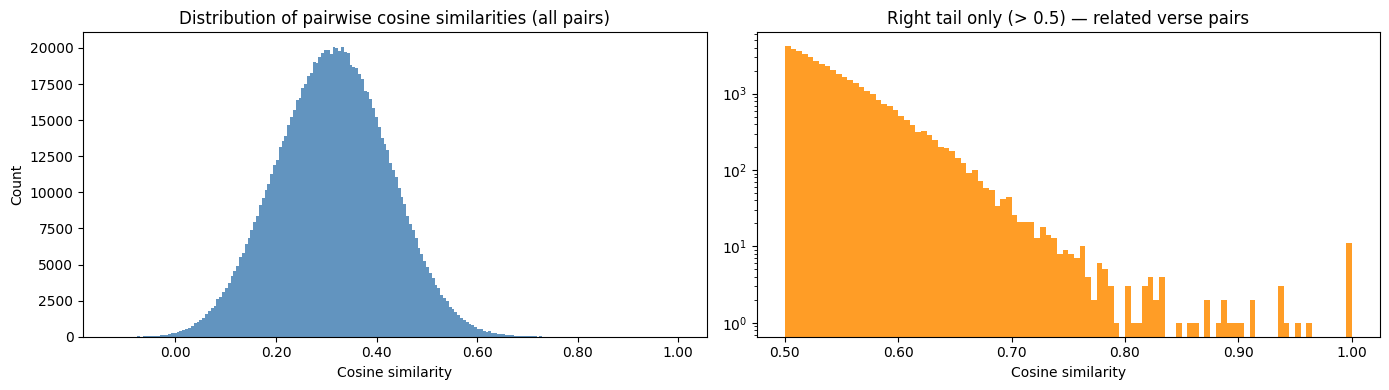

Mean:   0.3131
Median: 0.3137
Pairs > 0.5:  4.4%
Pairs > 0.7:  0.0%
Pairs > 0.85: 0.0%


In [3]:
rng = np.random.default_rng(42)
n = len(sim)
n_samples = 2_000_000

idx_i = rng.integers(0, n, size=n_samples)
idx_j = rng.integers(0, n, size=n_samples)
mask = idx_i < idx_j  # upper triangle only
sample = sim[idx_i[mask], idx_j[mask]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Full range
axes[0].hist(sample, bins=200, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_xlabel('Cosine similarity')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of pairwise cosine similarities (all pairs)')
axes[0].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

# Zoom into the right tail (>0.5) to see any secondary peak
axes[1].hist(sample[sample > 0.5], bins=100, color='darkorange', edgecolor='none', alpha=0.85)
axes[1].set_xlabel('Cosine similarity')
axes[1].set_title('Right tail only (> 0.5) — related verse pairs')
axes[1].xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.yscale('log')
plt.tight_layout()
plt.show()

print(f'Mean:   {sample.mean():.4f}')
print(f'Median: {np.median(sample):.4f}')
print(f'Pairs > 0.5:  {(sample > 0.5).mean() * 100:.1f}%')
print(f'Pairs > 0.7:  {(sample > 0.7).mean() * 100:.1f}%')
print(f'Pairs > 0.85: {(sample > 0.85).mean() * 100:.1f}%')

## 3. Genre-level heatmap

The Bible's 66 books can be grouped into broad literary genres. This analysis uses 10 genre categories — 5 from the Old Testament and 5 from the New:

| Testament | Genre | Examples |
|---|---|---|
| OT | Pentateuch | Genesis, Exodus, Leviticus … |
| OT | History | Joshua, Judges, Kings … |
| OT | Wisdom | Job, Psalms, Proverbs … |
| OT | Major Prophets | Isaiah, Jeremiah, Ezekiel … |
| OT | Minor Prophets | Hosea, Amos, Micah … |
| NT | Gospel | Matthew, Mark, Luke, John |
| NT | History | Acts |
| NT | Pauline Epistle | Romans, Corinthians, Galatians … |
| NT | General Epistle | Hebrews, James, Peter, John … |
| NT | Apocalyptic | Revelation |

For each pair of genres, we average the cosine similarity scores of all verse pairs drawn from those two genres. The result is a 10×10 grid where **darker / warmer colors mean the two genres tend to talk about similar things**, and cooler colors mean they are more distinct.

Look at the diagonal (genre compared to itself): these should always be the warmest — a genre is most similar to itself. Off-diagonal warm cells reveal surprising theological or thematic overlap across different parts of the Bible.

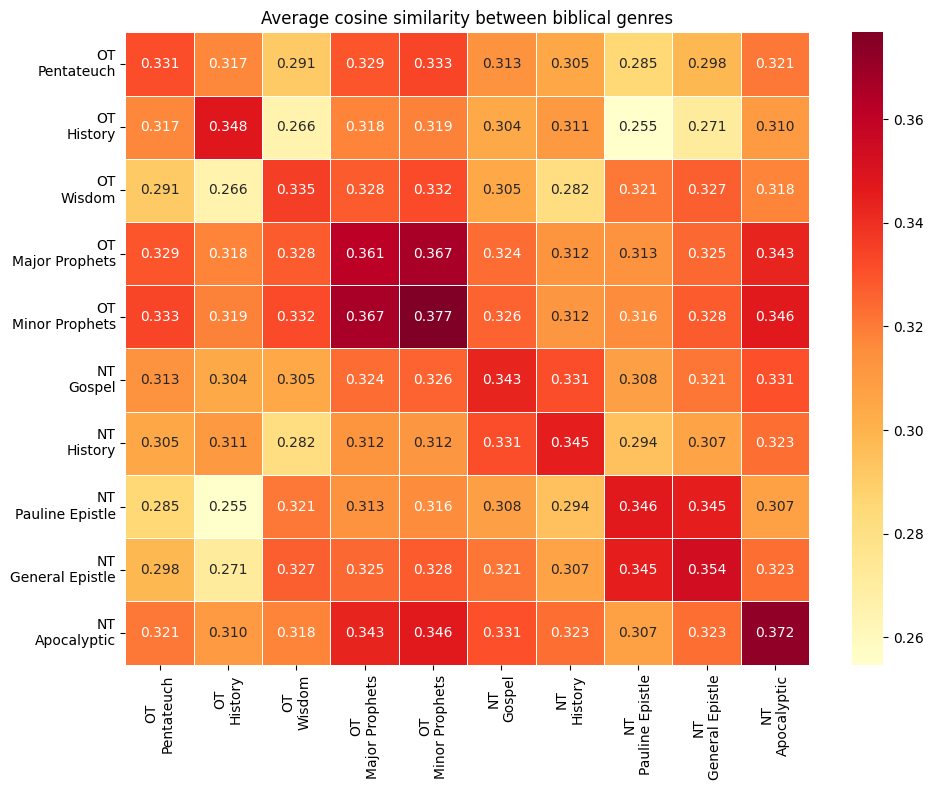

In [4]:
# Canonical genre order (OT then NT)
GENRE_ORDER = [
    ('OT', 'Pentateuch'),
    ('OT', 'History'),
    ('OT', 'Wisdom'),
    ('OT', 'Major Prophets'),
    ('OT', 'Minor Prophets'),
    ('NT', 'Gospel'),
    ('NT', 'History'),
    ('NT', 'Pauline Epistle'),
    ('NT', 'General Epistle'),
    ('NT', 'Apocalyptic'),
]
genre_labels = [f'{t}\n{g}' for t, g in GENRE_ORDER]

# Index verses by genre group
genre_indices = {
    key: [i for i, s in enumerate(segments) if (s['testament'], s['genre']) == key]
    for key in GENRE_ORDER
}

n_genres = len(GENRE_ORDER)
genre_sim = np.zeros((n_genres, n_genres))
for i, gi in enumerate(GENRE_ORDER):
    for j, gj in enumerate(GENRE_ORDER):
        block = sim[np.ix_(genre_indices[gi], genre_indices[gj])]
        genre_sim[i, j] = block.mean()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    genre_sim, annot=True, fmt='.3f', cmap='YlOrRd',
    xticklabels=genre_labels, yticklabels=genre_labels,
    ax=ax, vmin=genre_sim.min(), vmax=genre_sim.max(),
    linewidths=0.5, linecolor='white'
)
ax.set_title('Average cosine similarity between biblical genres')
plt.tight_layout()
plt.show()

## 4. Book-level heatmap

This section repeats the genre analysis at higher resolution: instead of 10 genre groups, we compare all 66 individual books. The matrix is now 66×66, and the books are arranged in canonical Bible order (Genesis through Revelation), so the Old Testament fills the top-left quadrant and the New Testament fills the bottom-right.

A white line is drawn across the diagonal to mark the boundary between the two Testaments.

**What to look for:**
- **Warm blocks along the diagonal** — books that are adjacent in the canon and share similar themes (e.g., the four Gospels should cluster together)
- **Warm off-diagonal blocks** — books from different parts of the Bible that share surprising thematic overlap (e.g., do any OT prophetic books resemble NT epistles?)
- **Cool zones** — books that are linguistically and thematically distinct from the rest (e.g., Proverbs or the Song of Solomon may stand apart)

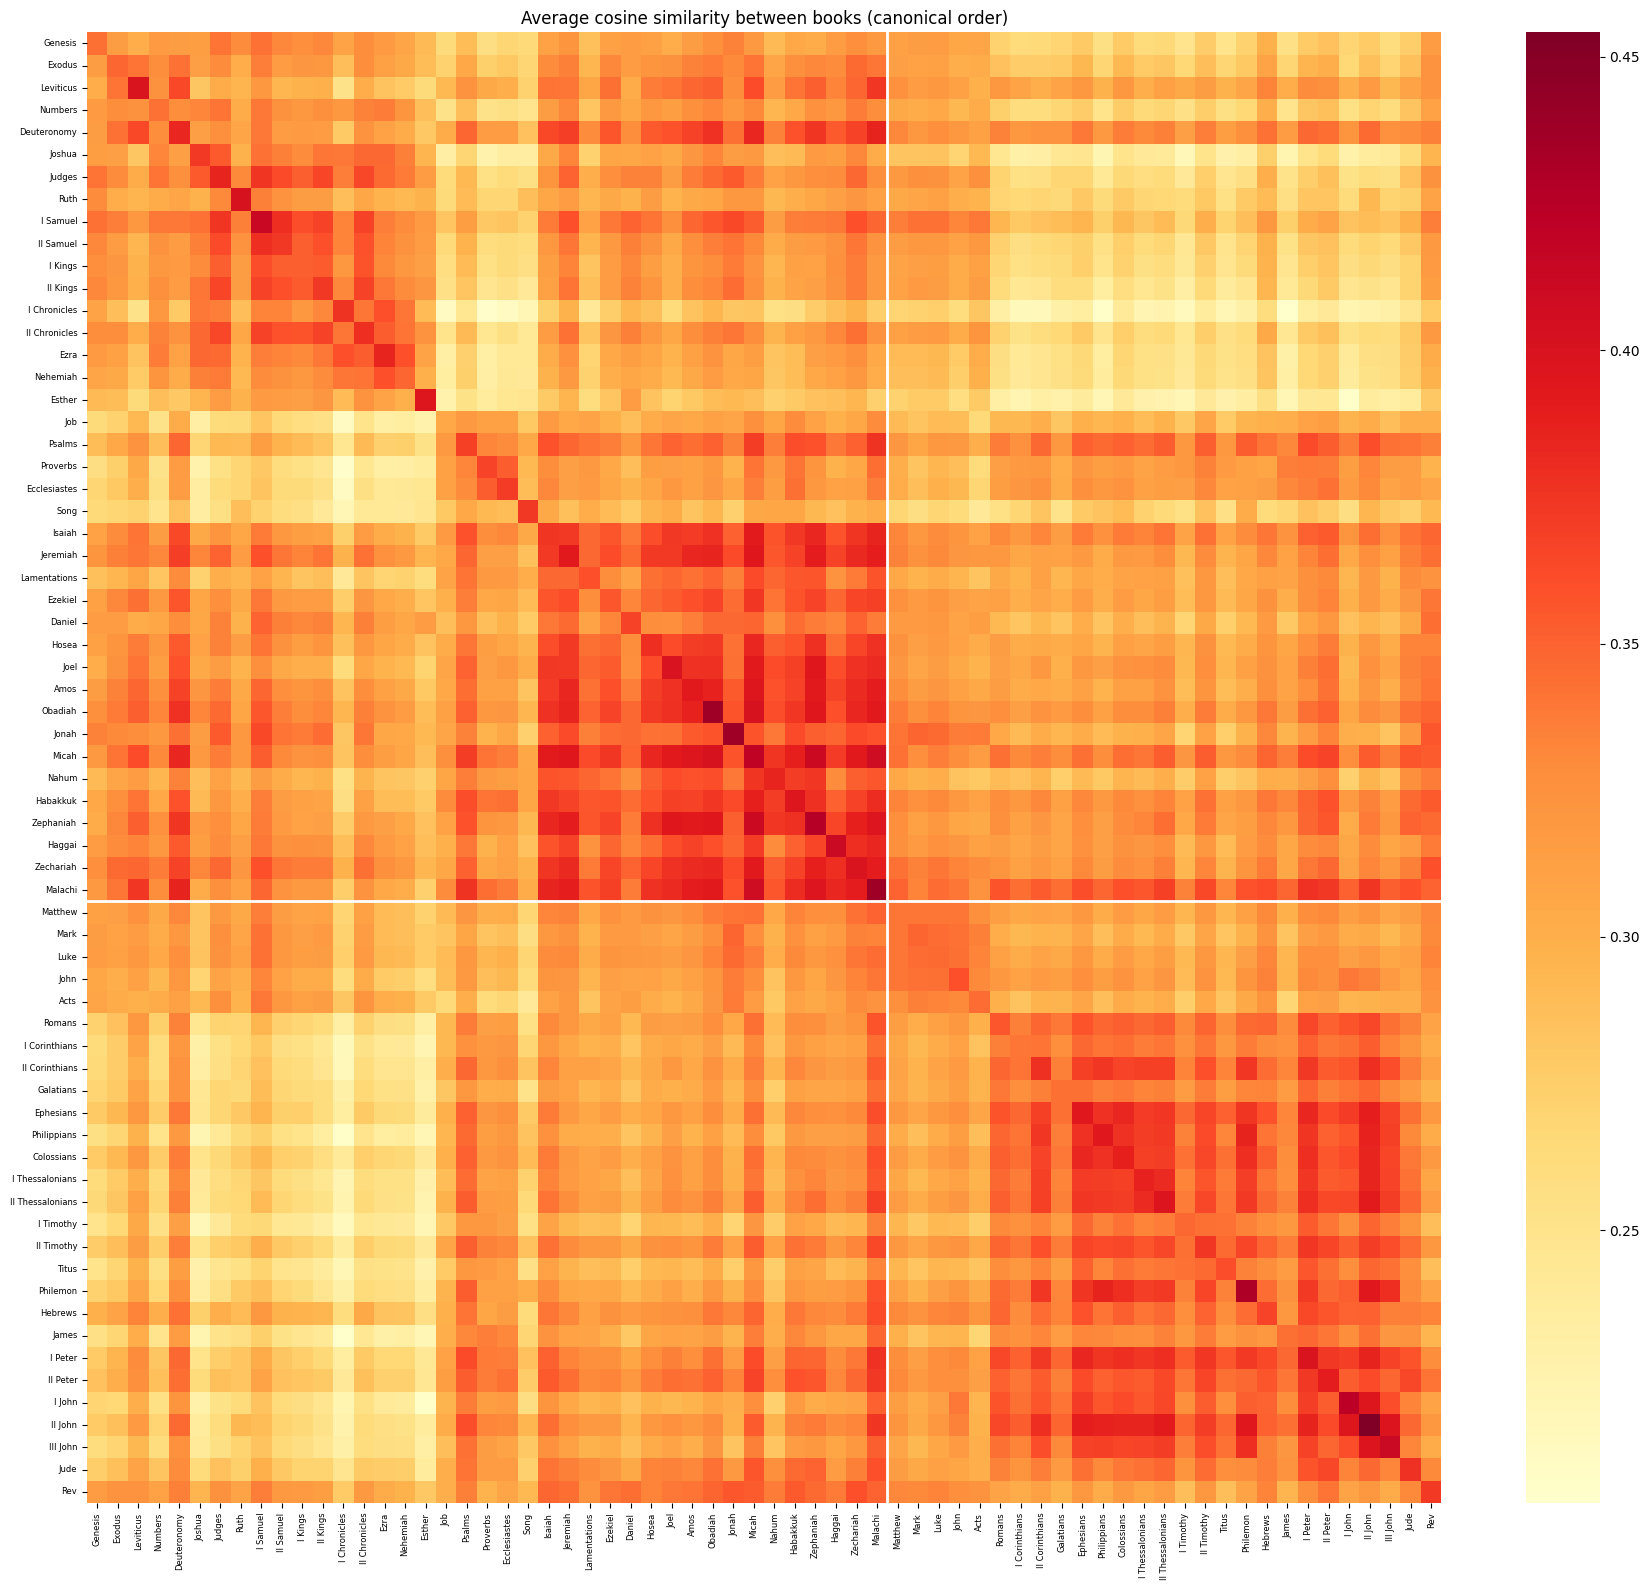

In [5]:
from sacred_semantics.corpus.books import BOOKS

book_names = [b.name for b in BOOKS]
book_indices = {name: [i for i, s in enumerate(segments) if s['book'] == name] for name in book_names}

n_books = len(book_names)
book_sim = np.zeros((n_books, n_books))
for i, bi in enumerate(book_names):
    for j, bj in enumerate(book_names):
        block = sim[np.ix_(book_indices[bi], book_indices[bj])]
        book_sim[i, j] = block.mean()

# Short labels for readability
short_labels = [
    b.replace('Song of Solomon', 'Song').replace('Revelation of John', 'Rev')
     .replace('I ', 'I ').replace('II ', 'II ').replace('III ', 'III ')
    for b in book_names
]

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    book_sim, cmap='YlOrRd',
    xticklabels=short_labels, yticklabels=short_labels,
    ax=ax, vmin=book_sim.min(), vmax=book_sim.max(),
)

# Draw OT/NT boundary
ot_count = sum(1 for b in BOOKS if b.testament == 'OT')
ax.axhline(ot_count, color='white', linewidth=2)
ax.axvline(ot_count, color='white', linewidth=2)

ax.set_title('Average cosine similarity between books (canonical order)')
ax.tick_params(axis='x', labelsize=6, rotation=90)
ax.tick_params(axis='y', labelsize=6)
plt.tight_layout()
plt.show()

## 5. Binary verse-level heatmap at multiple thresholds

Now we look at all 31,102 verses at once. To make this renderable, the matrix is downsampled to a 1,000×1,000 image — each pixel represents a small block of verses. The verses are sorted by genre in canonical order, so all Pentateuch verses come first, then History, and so on. The red lines mark the boundaries between genres.

A **binary** (black-and-white / blue-and-white) display is used: rather than showing the raw score, each cell is simply colored **blue if the similarity is at or above the threshold** and **white if it is below**. Four different threshold levels are shown side by side:

- **0.3** — a low bar; most verse pairs will pass it, so the image will be mostly blue
- **0.5** — moderate; a noticeable chunk of pairs drop out, and genre structure starts to appear
- **0.65** — stricter; only genuinely related pairs survive, and the genre-block pattern should sharpen
- **0.8** — very high; only near-identical or tightly parallel passages remain, and the image goes mostly white

**What the genre blocks mean:** If the model has correctly captured Biblical meaning, you should see darker (denser blue) squares along the diagonal — indicating that verses within the same genre are more similar to each other than to verses in other genres. This would confirm that the AI's sense of meaning aligns with the traditional literary structure of the Bible.

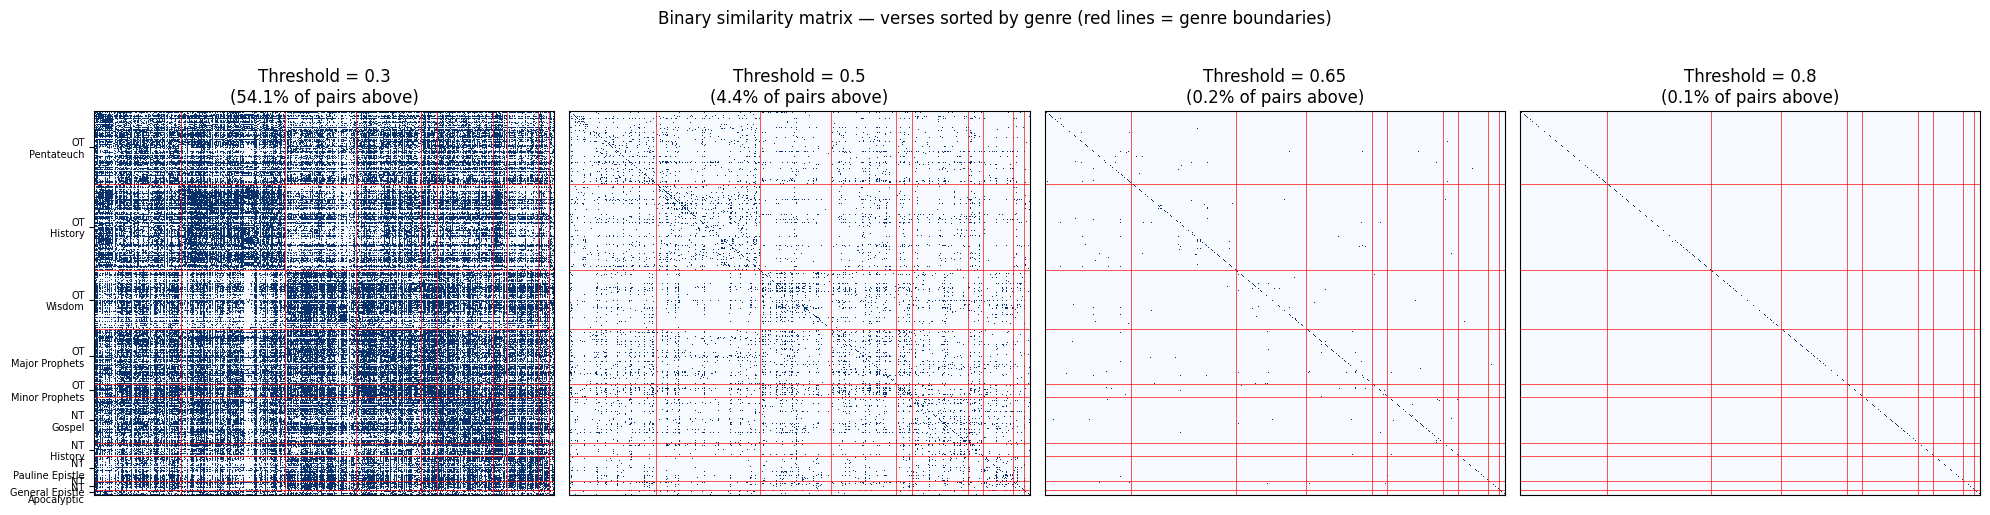

In [6]:
# Build sort order: group verses by genre in canonical order
genre_sort_key = {key: i for i, key in enumerate(GENRE_ORDER)}
sort_order = sorted(
    range(len(segments)),
    key=lambda i: (genre_sort_key[(segments[i]['testament'], segments[i]['genre'])], i)
)
sort_order = np.array(sort_order)

# Reorder the matrix (downsample to ~1000×1000 for display)
step = len(sort_order) // 1000
idx = sort_order[::step]
sim_sorted = sim[np.ix_(idx, idx)]

# Genre boundary positions in the downsampled matrix
boundaries = []
current_genre = None
for pos, orig_idx in enumerate(idx):
    s = segments[orig_idx]
    g = (s['testament'], s['genre'])
    if g != current_genre:
        if current_genre is not None:
            boundaries.append(pos)
        current_genre = g

thresholds = [0.3, 0.5, 0.65, 0.8]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, threshold in zip(axes, thresholds):
    binary = (sim_sorted >= threshold).astype(np.float32)
    ax.imshow(binary, cmap='Blues', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    for b in boundaries:
        ax.axhline(b, color='red', linewidth=0.6, alpha=0.8)
        ax.axvline(b, color='red', linewidth=0.6, alpha=0.8)
    pct = binary.mean() * 100
    ax.set_title(f'Threshold = {threshold}\n({pct:.1f}% of pairs above)')
    ax.set_xticks([])
    ax.set_yticks([])

# Genre labels on left
label_positions = []
prev = 0
for b in boundaries + [len(idx)]:
    label_positions.append((prev + b) // 2)
    prev = b
axes[0].set_yticks(label_positions)
axes[0].set_yticklabels([f'{t}\n{g}' for t, g in GENRE_ORDER], fontsize=7)

fig.suptitle('Binary similarity matrix — verses sorted by genre (red lines = genre boundaries)', y=1.02)
plt.tight_layout()
plt.show()

## 6. Interactive threshold slider

Use the slider below to explore the same binary verse map continuously, rather than at the four fixed levels above. Dragging the slider left lowers the threshold (more pairs shown as similar), and dragging it right raises it (only the most tightly related pairs survive).

**Things to try:**
- Start at **0.1** and slowly raise the threshold — watch the matrix go from almost entirely blue to mostly white
- Find the threshold where the genre-block structure (the squares along the diagonal) is clearest — this is the "signal" the model has learned
- Notice which genre blocks survive the longest as you raise the threshold — these are the parts of the Bible with the most internally consistent vocabulary and themes
- Look for off-diagonal blue squares that persist even at high thresholds — these are cross-genre passages that the model considers genuinely similar

In [7]:
import ipywidgets as widgets
from IPython.display import display

def show_binary(threshold: float) -> None:
    binary = (sim_sorted >= threshold).astype(np.float32)
    fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(binary, cmap='Blues', aspect='auto', interpolation='nearest', vmin=0, vmax=1)
    for b in boundaries:
        ax.axhline(b, color='red', linewidth=0.7, alpha=0.9)
        ax.axvline(b, color='red', linewidth=0.7, alpha=0.9)
    ax.set_yticks(label_positions)
    ax.set_yticklabels([f'{t} {g}' for t, g in GENRE_ORDER], fontsize=8)
    ax.set_xticks([])
    pct = binary.mean() * 100
    ax.set_title(f'Threshold = {threshold:.2f}  —  {pct:.1f}% of pairs above')
    plt.tight_layout()
    plt.show()

widgets.interact(
    show_binary,
    threshold=widgets.FloatSlider(min=0.1, max=0.95, step=0.05, value=0.5,
                                   description='Threshold', continuous_update=False)
)

interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='Threshold', max=0.95, min=0…

<function __main__.show_binary(threshold: float) -> None>

## 7. Find the most similar book

Type the name of any book of the Bible and click **Search** to see which other books are most semantically similar to it, ranked by their average cosine similarity score. This uses the same book-level similarity matrix computed in section 4.

Partial names work (e.g. "cor" matches "I Corinthians"), and capitalisation does not matter.

In [8]:
import ipywidgets as widgets
from IPython.display import display, clear_output

output = widgets.Output()

def find_similar_books(book_input: str) -> None:
    with output:
        clear_output()
        query = book_input.strip()
        if not query:
            return

        # Exact match first, then case-insensitive, then partial
        if query in book_names:
            matched = query
        else:
            lower = query.lower()
            exact_ci = [b for b in book_names if b.lower() == lower]
            partial  = [b for b in book_names if lower in b.lower()]
            candidates = exact_ci or partial
            if not candidates:
                print(f'No book found matching "{query}".')
                print(f'Available books: {", ".join(book_names)}')
                return
            matched = candidates[0]
            if len(candidates) > 1:
                print(f'Matched "{matched}" (other possibilities: {", ".join(candidates[1:])})\n')

        idx = book_names.index(matched)
        sims = book_sim[idx].copy()
        sims[idx] = -1  # exclude self-comparison
        ranked = np.argsort(sims)[::-1][:10]

        print(f'Top 10 books most similar to  {matched}:\n')
        print(f'  {"Rank":<5} {"Book":<30} {"Similarity":>10}')
        print(f'  {"-"*5} {"-"*30} {"-"*10}')
        for rank, j in enumerate(ranked, 1):
            print(f'  {rank:<5} {book_names[j]:<30} {sims[j]:>10.4f}')

text_input = widgets.Text(
    placeholder='e.g. Psalms',
    description='Book:',
    layout=widgets.Layout(width='320px')
)
button = widgets.Button(description='Search', button_style='primary')

def on_click(_):
    find_similar_books(text_input.value)

button.on_click(on_click)
text_input.on_submit(lambda _: find_similar_books(text_input.value))

display(widgets.HBox([text_input, button]), output)

C:\Users\Joey Kilgore\AppData\Local\Temp\ipykernel_43888\1716660588.py:51: DeprecationWarning: on_submit is deprecated. Instead, set the .continuous_update attribute to False and observe the value changing with: mywidget.observe(callback, 'value').
  text_input.on_submit(lambda _: find_similar_books(text_input.value))


Output()